# Elevator RL vs SCAN Simulation Demo

Runs the trained PPO model and SCAN baseline against the same guest sequence side-by-side.

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../Elevator_Reinforcement_Training')
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import imageio
from IPython.display import Video, display
from sb3_contrib import MaskablePPO
from MultiElevatorEnv import MultiElevatorEnv
from scan_baseline import scan_action

%matplotlib inline

## Load model and create two envs (RL + SCAN) with identical guest sequences

In [2]:
SEED = 42

model = MaskablePPO.load('../Elevator_Reinforcement_Training/checkpoints_v2/ppo_elevator_episode_200.zip')

def make_env():
    return MultiElevatorEnv(
        num_elevators=1,
        num_floors=10,
        max_passengers=5,
        max_guests=80,
        spawn_intervall=120 * 60,
        working_time_mean=3600,
        working_time_std=300,
    )

def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)

seed_all(SEED)
rl_env = make_env()
rl_obs, rl_info = rl_env.reset(seed=SEED)

seed_all(SEED)
scan_env = make_env()
scan_obs, scan_info = scan_env.reset(seed=SEED)

print(f'RL env ready:   {rl_env.num_elevators} elevator, {rl_env.num_floors} floors, {rl_env.max_guests} guests')
print(f'SCAN env ready: {scan_env.num_elevators} elevator, {scan_env.num_floors} floors, {scan_env.max_guests} guests')

RL env ready:   1 elevator, 10 floors, 80 guests
SCAN env ready: 1 elevator, 10 floors, 80 guests


## Side-by-side renderer

In [3]:
def make_side_by_side_renderer(rl_env, scan_env):
    num_floors = rl_env.num_floors

    fig = plt.figure(figsize=(14, 6), dpi=80)
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    titles = ['RL (PPO ep200)', 'SCAN Baseline']
    envs = [rl_env, scan_env]

    elev_rects_all = []
    elev_texts_all = []
    wait_texts_all = []
    title_texts = []

    for ax, env, title in zip(axes, envs, titles):
        ax.set_xlim(-0.5, 2.0)
        ax.set_ylim(-0.5, num_floors - 0.5)
        ax.set_yticks(range(num_floors))
        ax.set_yticklabels([f'F{i}' for i in range(num_floors)])
        ax.set_xticks([])
        ax.set_title(title, fontsize=11, fontweight='bold')
        for f in range(num_floors + 1):
            ax.axhline(y=f - 0.5, color='#ddd', linewidth=0.5)

        rect = FancyBboxPatch(
            (-0.35, -0.35), 0.7, 0.7,
            boxstyle='round,pad=0.05', facecolor='#2196F3', edgecolor='black', linewidth=1.5,
        )
        ax.add_patch(rect)
        elev_rects_all.append([rect])
        txt = ax.text(0, 0, '0', ha='center', va='center', fontsize=16, fontweight='bold', color='white')
        elev_texts_all.append([txt])

        wt = [ax.text(1.1, f, '', ha='left', va='center', fontsize=9, color='#d32f2f') for f in range(num_floors)]
        wait_texts_all.append(wt)
        title_texts.append(ax.text(0.5, -0.47, '', ha='center', va='top',
                                    transform=ax.get_xaxis_transform(), fontsize=8, color='#333'))

    fig.tight_layout()

    def render():
        for idx, (ax, env, elev_rects, elev_texts, wait_texts, stat_txt) in enumerate(
            zip(axes, envs, elev_rects_all, elev_texts_all, wait_texts_all, title_texts)
        ):
            elev = env.elevators[0]
            color = '#4CAF50' if elev.door_open else '#2196F3'
            elev_rects[0].remove()
            rect = FancyBboxPatch(
                (-0.35, elev.current_floor - 0.35), 0.7, 0.7,
                boxstyle='round,pad=0.05', facecolor=color, edgecolor='black', linewidth=1.5,
            )
            ax.add_patch(rect)
            elev_rects[0] = rect
            elev_texts[0].set_position((0, elev.current_floor))
            elev_texts[0].set_text(str(len(elev.passengers)))

            for f in range(env.num_floors):
                count = sum(1 for g in env.waiting_guests if g.current_floor == f)
                wait_texts[f].set_text(f'{count}w' if count > 0 else '')

            done = len(env.left_guests)
            sim_s = env.episode_steps
            h = 8 + sim_s // 3600
            m = (sim_s % 3600) // 60
            stat_txt.set_text(
                f'{h:02}:{m:02}  waiting={len(env.waiting_guests)}  '
                f'riding={len(env.guests_in_elevator)}  done={done}/{env.max_guests}'
            )

        fig.canvas.draw()
        buf = fig.canvas.buffer_rgba()
        return np.asarray(buf)[:, :, :3].copy()

    def close():
        plt.close(fig)

    return render, close


## Record the side-by-side simulation

In [4]:
def make_renderer(env):
    num_floors = env.num_floors
    num_elevators = env.num_elevators

    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=80)
    ax.set_xlim(-0.5, num_elevators + 1.5)
    ax.set_ylim(-0.5, num_floors - 0.5)
    ax.set_yticks(range(num_floors))
    ax.set_yticklabels([f'F{i}' for i in range(num_floors)])
    ax.set_xticks(range(num_elevators))
    ax.set_xticklabels([f'E{i}' for i in range(num_elevators)])
    for f in range(num_floors + 1):
        ax.axhline(y=f - 0.5, color='#ddd', linewidth=0.5)

    elev_rects = []
    elev_texts = []
    for idx in range(num_elevators):
        rect = FancyBboxPatch(
            (idx - 0.35, -0.35), 0.7, 0.7,
            boxstyle='round,pad=0.05', facecolor='#2196F3', edgecolor='black', linewidth=1.5,
        )
        ax.add_patch(rect)
        elev_rects.append(rect)
        txt = ax.text(idx, 0, '0', ha='center', va='center', fontsize=16, fontweight='bold', color='white')
        elev_texts.append(txt)

    wait_texts = []
    for floor in range(num_floors):
        txt = ax.text(num_elevators + 0.3, floor, '', ha='left', va='center', fontsize=10, color='#d32f2f')
        wait_texts.append(txt)

    title_text = ax.set_title('', fontsize=11, fontweight='bold')
    fig.tight_layout()

    def render():
        for idx, elev in enumerate(env.elevators):
            color = '#4CAF50' if elev.door_open else '#2196F3'
            elev_rects[idx].remove()
            rect = FancyBboxPatch(
                (idx - 0.35, elev.current_floor - 0.35), 0.7, 0.7,
                boxstyle='round,pad=0.05', facecolor=color, edgecolor='black', linewidth=1.5,
            )
            ax.add_patch(rect)
            elev_rects[idx] = rect
            elev_texts[idx].set_position((idx, elev.current_floor))
            elev_texts[idx].set_text(str(len(elev.passengers)))

        for floor in range(num_floors):
            count = sum(1 for g in env.waiting_guests if g.current_floor == floor)
            wait_texts[floor].set_text(f'{count} waiting' if count > 0 else '')

        sim_seconds = env.episode_steps
        hours = 8 + sim_seconds // 3600
        minutes = (sim_seconds % 3600) // 60
        done = len(env.left_guests)
        title_text.set_text(
            f'Time {hours:02}:{minutes:02}  |  '
            f'Waiting: {len(env.waiting_guests)}  |  '
            f'Riding: {len(env.guests_in_elevator)}  |  '
            f'Done: {done}/{env.max_guests}'
        )

        fig.canvas.draw()
        buf = fig.canvas.buffer_rgba()
        return np.asarray(buf)[:, :, :3].copy()

    def close():
        plt.close(fig)

    return render, close

## Record both simulations

Steps both envs in lockstep. RL uses model.predict(), SCAN uses scan_action().

In [5]:
rl_terminated = rl_truncated = False
scan_terminated = scan_truncated = False
step_count = 0
capture_every = 20
frames = []

render_frame, close_renderer = make_side_by_side_renderer(rl_env, scan_env)

print('Recording simulation...')
while not (rl_terminated or rl_truncated or scan_terminated or scan_truncated):
    # RL action
    rl_masks = rl_info['action_mask']
    rl_action, _ = model.predict(rl_obs, action_masks=rl_masks[0], deterministic=True)
    rl_obs, _, rl_terminated, rl_truncated, rl_info = rl_env.step([int(rl_action[0])])

    # SCAN action
    scan_action_val = scan_action(scan_env.elevators[0], scan_env.waiting_guests, scan_env.num_floors)
    scan_obs, _, scan_terminated, scan_truncated, scan_info = scan_env.step([scan_action_val])

    step_count += 1
    if step_count % capture_every == 0:
        frames.append(render_frame())

close_renderer()
print(f'Done! {len(frames)} frames over {step_count} steps.')
print(f'RL   — guests done: {len(rl_env.left_guests)}/{rl_env.max_guests}  reward: {rl_env.total_reward:.0f}')
print(f'SCAN — guests done: {len(scan_env.left_guests)}/{scan_env.max_guests}  reward: {scan_env.total_reward:.0f}')

video_path = 'elevator_sim_comparison.mp4'
imageio.mimwrite(video_path, frames, fps=15, quality=8)
print(f'Video saved: {video_path}')

Recording simulation...


/tmp/ipykernel_745473/2170534038.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Step:  12516
Guests_left_building:  80
Guests_in_building:  0
Total_reward:  10985.899999999196
Done! 625 frames over 12516 steps.
RL   — guests done: 80/80  reward: 10986
SCAN — guests done: 15/80  reward: -187332
Video saved: elevator_sim_comparison.mp4


## Play the comparison video

In [6]:
display(Video('elevator_sim_comparison.mp4', embed=True, width=900))

## Results comparison

In [7]:
import pandas as pd

def summarise(env, label):
    df = pd.DataFrame(env.logs)
    if df.empty:
        print(f'{label}: no log entries')
        return
    drive_df = df[df['mode'] == 'elevator_drive']
    wait_df  = df[df['mode'] == 'elevator_waiting']
    print(f'{label}:')
    print(f'  Guests done:    {len(env.left_guests)}/{env.max_guests}')
    print(f'  Avg wait time:  {wait_df["wait_time"].mean():.0f}s')
    print(f'  Avg ride time:  {drive_df["travel_time"].mean():.0f}s')
    print(f'  Total reward:   {env.total_reward:.0f}')
    print()

summarise(rl_env,   'RL (PPO ep200)')
summarise(scan_env, 'SCAN Baseline')

RL (PPO ep200):
  Guests done:    80/80
  Avg wait time:  37s
  Avg ride time:  42s
  Total reward:   10986

SCAN Baseline:
  Guests done:    15/80
  Avg wait time:  33s
  Avg ride time:  39s
  Total reward:   -187332



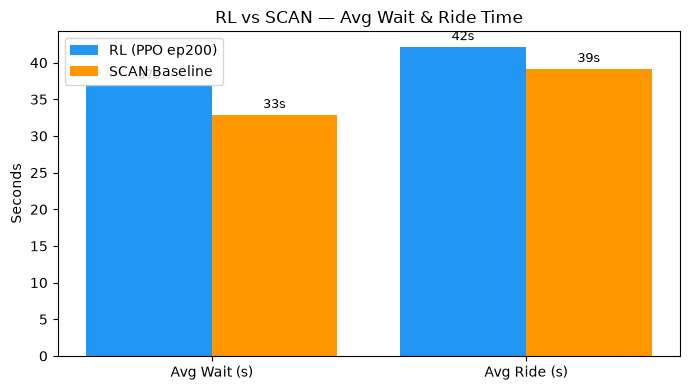

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def get_metrics(env):
    df = pd.DataFrame(env.logs)
    if df.empty:
        return None
    return {
        'wait': df[df['mode'] == 'elevator_waiting']['wait_time'].mean(),
        'ride': df[df['mode'] == 'elevator_drive']['travel_time'].mean(),
        'done': len(env.left_guests),
    }

rl_m   = get_metrics(rl_env)
scan_m = get_metrics(scan_env)

if rl_m and scan_m:
    labels = ['Avg Wait (s)', 'Avg Ride (s)']
    rl_vals   = [rl_m['wait'],   rl_m['ride']]
    scan_vals = [scan_m['wait'], scan_m['ride']]

    x = range(len(labels))
    fig, ax = plt.subplots(figsize=(7, 4))
    bars1 = ax.bar([i - 0.2 for i in x], rl_vals,   0.4, label='RL (PPO ep200)', color='#2196F3')
    bars2 = ax.bar([i + 0.2 for i in x], scan_vals, 0.4, label='SCAN Baseline',  color='#FF9800')
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylabel('Seconds')
    ax.set_title('RL vs SCAN — Avg Wait & Ride Time')
    ax.legend()
    for bar in bars1 + bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.0f}s', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()